### 📌 DBSCAN – **Density-Based Spatial Clustering of Applications with Noise**

---

DBSCAN is a powerful clustering algorithm that **detects clusters of arbitrary shape** and **filters out noise** — unlike K-means, it doesn't need the number of clusters in advance.

---

## 🧠 Key Intuition

> If a region has **high point density**, it's likely a cluster.
> Sparse regions are considered **noise or boundary**.

---

## 🔸 Parameters

1. **`eps`** (ε):
   Maximum radius of the neighborhood around a point.

2. **`min_samples`**:
   Minimum number of points required to form a **dense region** (including the point itself).

---

## 🔹 Terminology

| Term             | Meaning                                                               |
| ---------------- | --------------------------------------------------------------------- |
| **Core point**   | Has ≥ `min_samples` in its `eps` neighborhood                         |
| **Border point** | Has < `min_samples`, but is in the `eps` neighborhood of a core point |
| **Noise point**  | Not a core point and not in any core point’s neighborhood             |

---

## 🔸 DBSCAN Algorithm Steps

1. For each unvisited point:

   * If it has ≥ `min_samples` points within `eps`: **core point → new cluster**
   * Expand the cluster by including all density-reachable points

2. Points not reachable from any core point → labeled as **noise**

---

## 🧩 Example

Let:

* `eps = 0.5`
* `min_samples = 4`

Imagine a dense blob of 10 nearby points:

* All within 0.5 units of each other
* Each has ≥ 4 neighbors → all **core points**
* Cluster is formed from this group

Now imagine a few isolated points:

* Fewer than 4 neighbors → **noise points**

---

## 🔹 Advantages

✅ No need to specify number of clusters
✅ Handles **arbitrary-shaped** clusters
✅ Filters **outliers** naturally
✅ Good for **spatial** or **density-based** data

---

## 🔸 Limitations

❌ Fails if clusters have **varying densities**
❌ Choosing `eps` is tricky
❌ Slow for very high-dimensional data (unless optimized)

---

## 🧪 Code Example (with `sklearn`)

```python
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=300, noise=0.05)
model = DBSCAN(eps=0.3, min_samples=5)
labels = model.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow')
plt.title("DBSCAN Clustering")
plt.show()
```

---

## 🔹 Summary Table

| Feature         | DBSCAN               |
| --------------- | -------------------- |
| Type            | Density-based        |
| Needs k?        | ❌ No                 |
| Handles noise?  | ✅ Yes                |
| Cluster shapes  | Arbitrary            |
| Key hyperparams | `eps`, `min_samples` |

---



DBSCAN is a clustering algorithm (like K-Means)

### Problems of K-means

1) Need to give no of clusters ourselves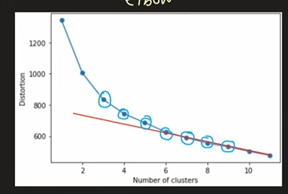
2) Very sensitive to outliers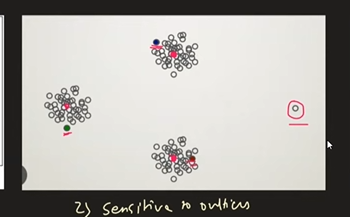
3) Doesn't work well for non-spherical clusters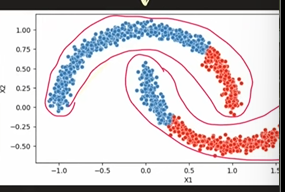

K-means is a centroid based clustering algorithm. DBSCAN uses Density Based Clustering

DBSCAN - Density Based Spatial Clustering Applications with Noise

Density is measured using epsilon which is the radius of the circle and we count the no of points in it

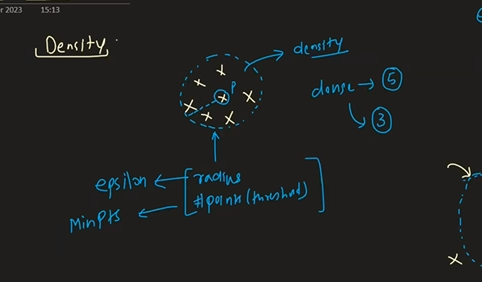

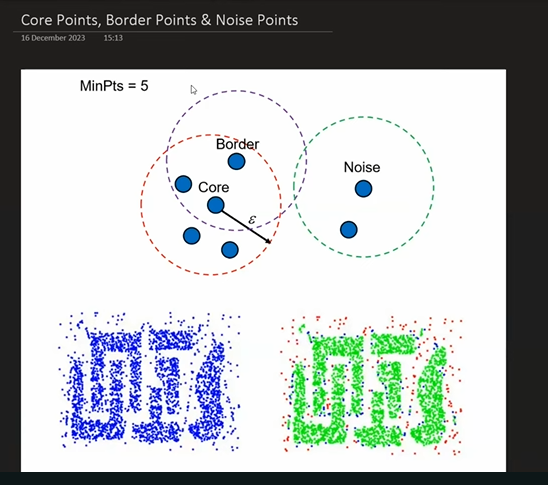

### 🧠 DBSCAN: Core, Border, and Noise Points (With Visual Intuition)

---

In **DBSCAN**, data points are classified based on the **density of their neighborhood** using two key parameters:

* `eps`: neighborhood radius
* `min_samples`: minimum points required in the `eps`-neighborhood

---

## 🔹 1. Core Point

> A point is a **core point** if it has at least `min_samples` points (including itself) **within distance `eps`**.

📌 This means it lies in a **dense region**, enough to "start" a cluster.

### 🔸 Formal:

```math
\text{Core point } x_i \text{ if } |\mathcal{N}_{\varepsilon}(x_i)| \geq \text{min\_samples}
```

Where:

* $\mathcal{N}_{\varepsilon}(x_i) = \{x_j \mid \text{distance}(x_i, x_j) \leq \varepsilon \}$

---

## 🔹 2. Border Point

> A **border point** is **not a core**, but lies within `eps` of a core point.

📌 It’s **close enough to a dense area**, but doesn’t have enough neighbors to be dense itself.

---

## 🔹 3. Noise Point (Outlier)

> A **noise point** (or outlier) is **neither a core nor a border** point.

📌 It has too few neighbors and doesn't lie close to any dense cluster.

---

## 🎯 Summary Table

| Point Type   | Min Samples in `eps` | In neighborhood of Core Point? | Belongs to Cluster? |
| ------------ | -------------------- | ------------------------------ | ------------------- |
| Core Point   | ✅ Yes                | ✅ (self)                       | ✅ Yes               |
| Border Point | ❌ No                 | ✅ Yes                          | ✅ Yes               |
| Noise Point  | ❌ No                 | ❌ No                           | ❌ No                |

---

## 🧠 Visual Example

```text
Legend:
• = data point
C = core
B = border
N = noise

             eps=0.5, min_samples=4

             • • •
             • C •
            • • • •
                  B          N
```

* `C`: has ≥ 4 neighbors within `eps` → **core**
* `B`: has < 4, but within `eps` of `C` → **border**
* `N`: isolated → **noise**

---



### 🧠 Density-Connected Points in DBSCAN

In DBSCAN, clustering is based on **density connectivity**, which helps form clusters by linking points through chains of neighbors.

---

## 🔸 1. Directly Density-Reachable

A point $p$ is **directly density-reachable** from point $q$ if:

1. $p \in \mathcal{N}_{\varepsilon}(q)$ — i.e., within distance $\varepsilon$ of $q$
2. $q$ is a **core point**

> ✅ Only core points can **directly reach** other points

---

## 🔸 2. Density-Reachable

A point $p$ is **density-reachable** from point $q$ if there exists a chain of points:

```text
q → p₁ → p₂ → ... → pₖ = p
```

Such that:

* Each point is **directly density-reachable** from the previous one
* The chain **starts at a core point**
* All intermediate points must also be **core points**
* The final point $p$ can be **core or border**

> ✅ Used to expand clusters outward from core points

---

## 🔸 3. Density-Connected

Two points $p$ and $q$ are **density-connected** if there exists a third point $o$ such that:

* Both $p$ and $q$ are **density-reachable from $o$**

This is the **core idea** used to define whether two points belong to the **same cluster**.

---

### 📌 Summary Table

| Term                       | Description                                                                    |
| -------------------------- | ------------------------------------------------------------------------------ |
| Directly Density-Reachable | Point is in `eps` neighborhood of a core point                                 |
| Density-Reachable          | Chain of directly density-reachable points from a core point                   |
| Density-Connected          | Two points share a common core ancestor and are both density-reachable from it |

---

### 🧠 Visual Intuition

```
   ● = core
   x = border
   . = noise

   ● — ● — ● — x     ← All these are density-connected (via core chain)
         |
        ●

       .    ← Not connected (noise)
```

* All solid circles and the x are in the **same cluster** (density-connected)
* The dot is not connected and is labeled **noise**

---




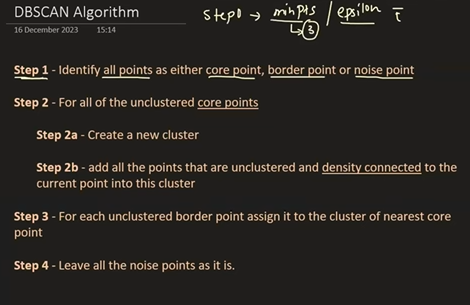

### Demo

In [1]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt


X = np.array([[1, 2], [2, 2], [2, 3],[8, 7], [8, 8], [25, 80]])


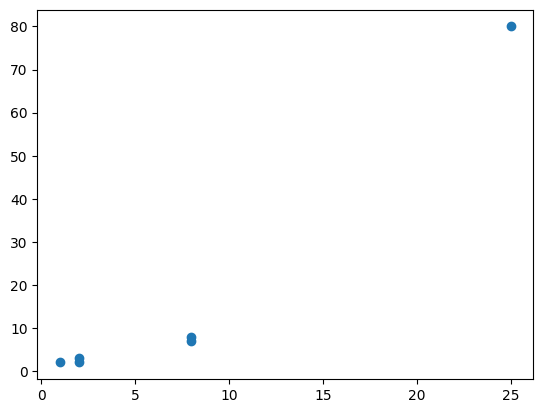

In [2]:
plt.scatter(X[:, 0], X[:, 1])
plt.show()


In [3]:
db = DBSCAN(eps=10, min_samples=2)

db.fit(X)
db.labels_

array([ 0,  0,  0,  0,  0, -1], dtype=int64)

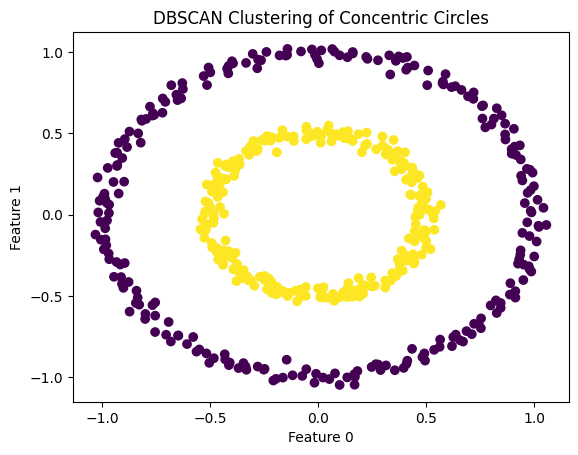

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import numpy as np

# Create a concentric circle dataset
X, _ = make_circles(n_samples=500, factor=.5, noise=.03, random_state=4)

# Apply DBSCAN to the dataset
dbscan = DBSCAN(eps=0.1, min_samples=5)
clusters = dbscan.fit_predict(X)

# Plotting
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', marker='o')
plt.title("DBSCAN Clustering of Concentric Circles")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()


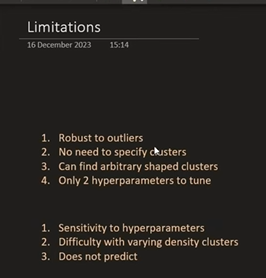

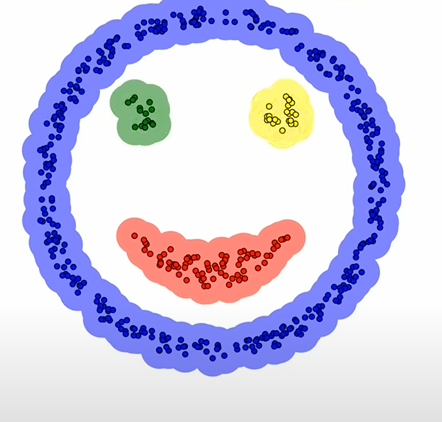